In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

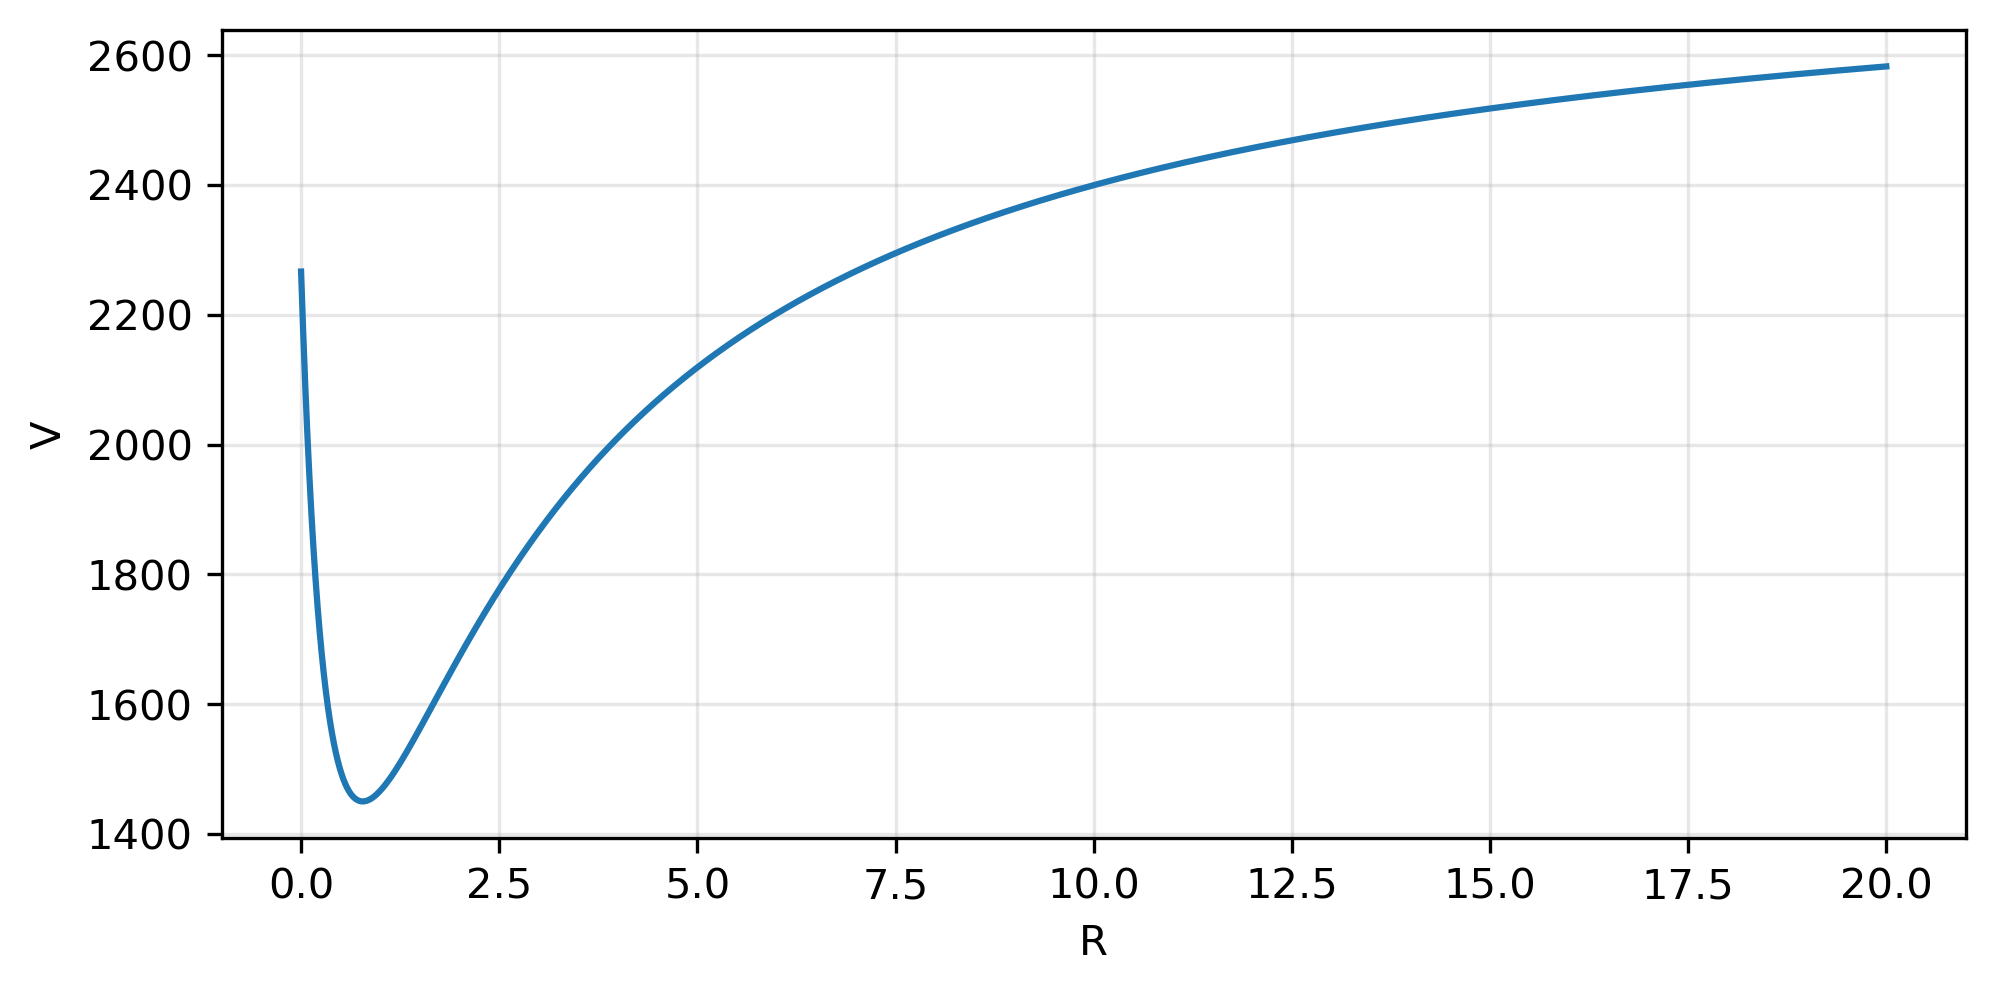

In [20]:
R = np.linspace(0, 20, 10000)  # definimos un ramdo arbitrario de R

# definimos el volumen a graficar
V = (
    250
    * (1 + R)
    * (
        9.067
        - 100 / 3 * (R / (R + 1) * 0.8) ** 3
        + 50 * (R / (R + 1) * 0.8) ** 2
        - 30 * (R / (R + 1) * 0.8)
    )
)

# plot
fig, ax = plt.subplots(figsize=(7.5, 3.5), dpi=300)
ax.plot(R, V, zorder=3)
ax.set_xlabel("R")
ax.set_ylabel("V")

ax.grid(alpha=0.3, zorder=0)
fig.savefig("ayu5_reciclo_rxn_multiples.pdf", bbox_inches="tight", pad_inches=0.01, transparent=True)


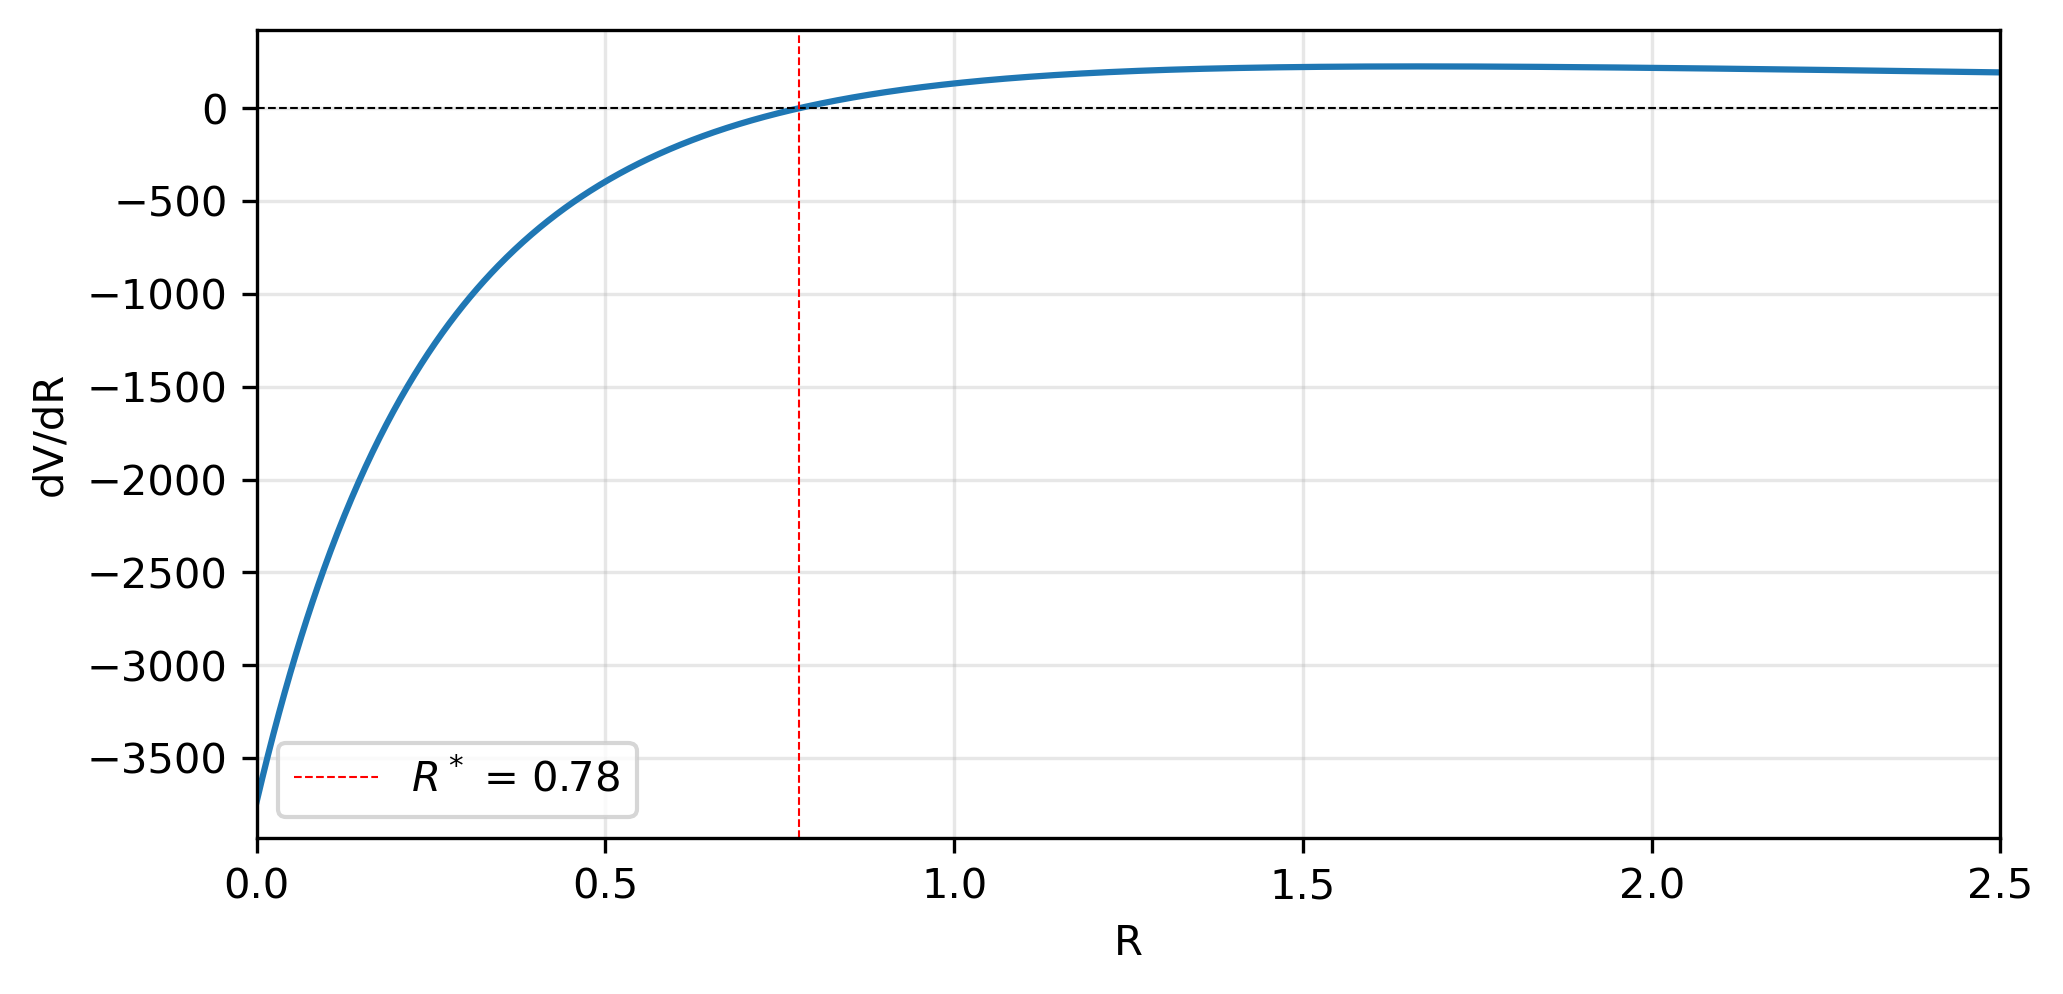

In [48]:
dV_dR = (-3733.25 + 4800.25 * R + 0.25 * R**2 + 0.0833333 * R**3) / (1 + R) ** 3
# derivada
# plot
fig, ax = plt.subplots(figsize=(7.5, 3.5), dpi=300)
ax.plot(R, dV_dR)
ax.set_xlabel("R")
ax.set_ylabel("dV/dR")
ax.set_xlim(0, 2.5)
ax.grid(alpha=0.3)
ax.axhline(0, color="k", lw=0.5, ls="--")
# 0
index = np.where(np.isclose(dV_dR, 0, atol=5e-1))
R_critical = R[index]
ax.axvline(R_critical, color="r", lw=0.5, ls="--", label = r'$R^*$ = ' + f'{R_critical[0]:.2f}')
ax.legend()
fig.savefig("ayu5_reciclo_rxn_multiples_derivada.pdf", bbox_inches="tight", pad_inches=0.01, transparent=True)

R* = 0.78


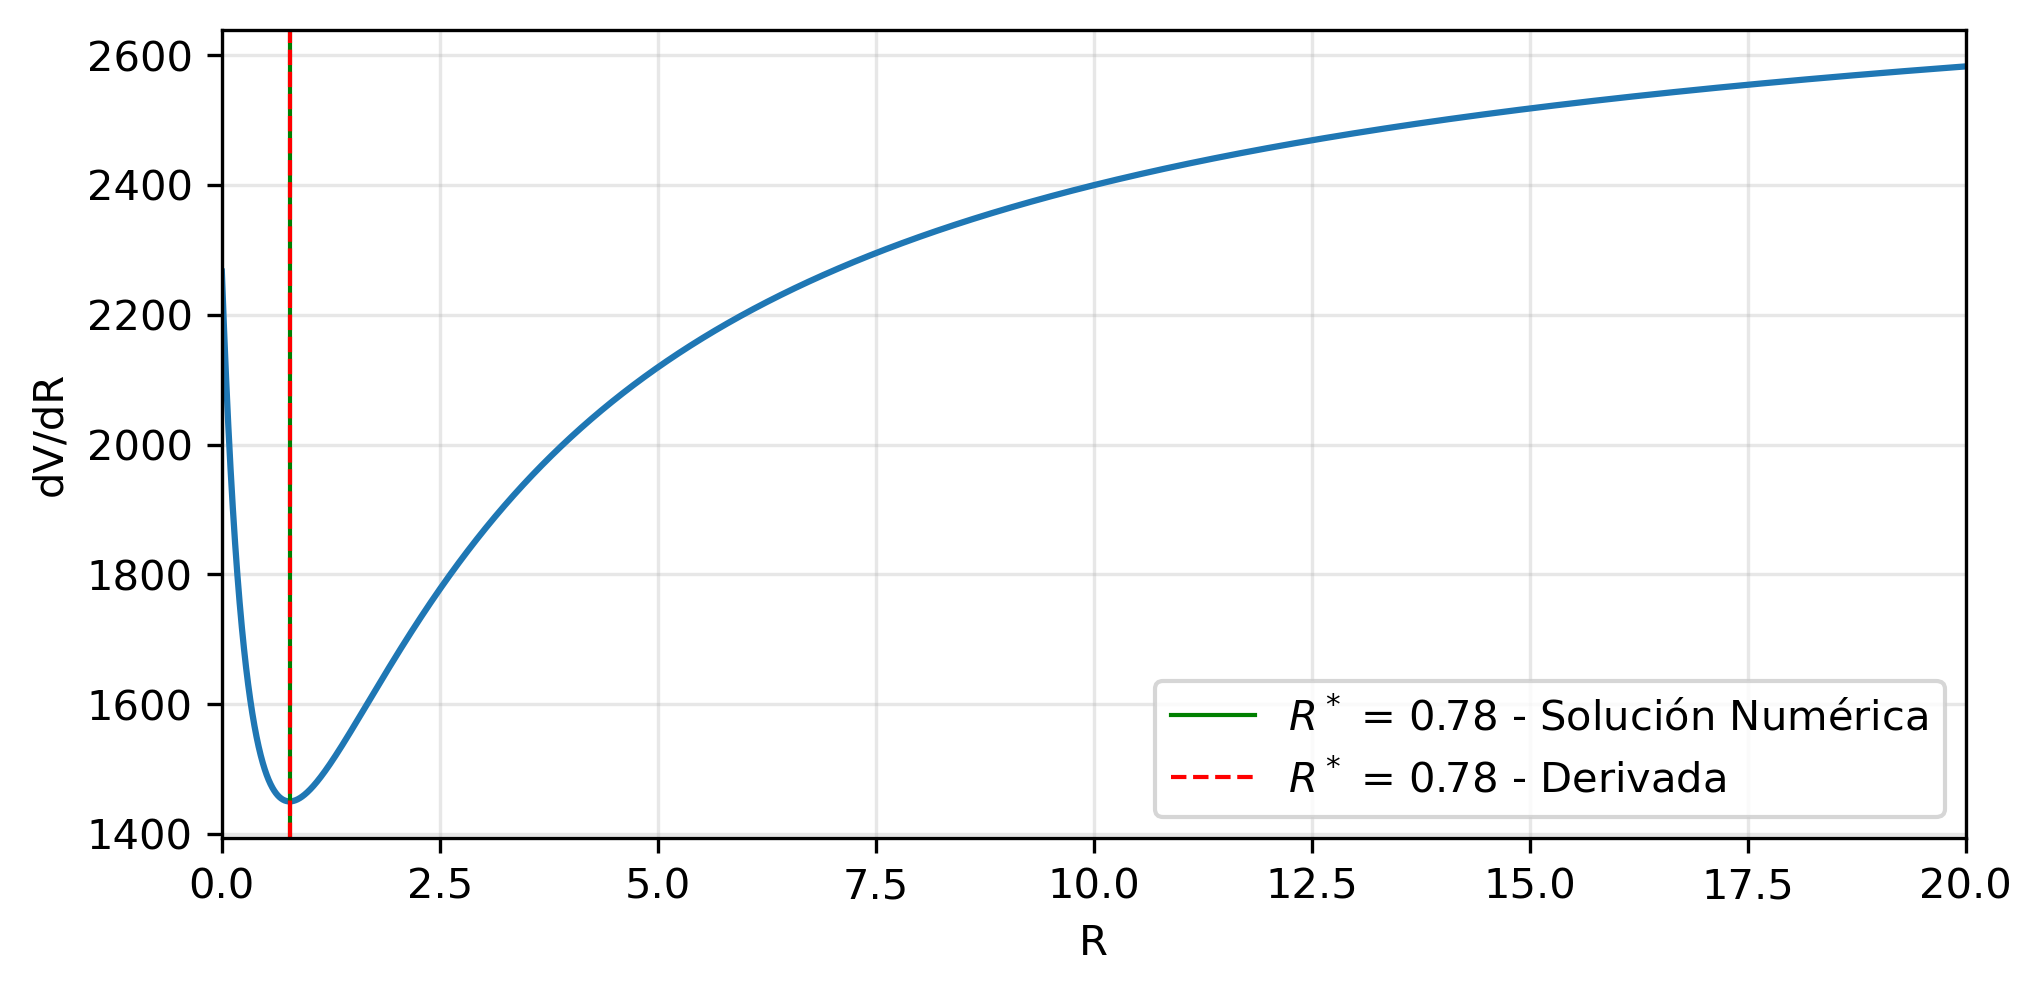

In [59]:
# solving the equation
def f(R):
    # Expresión que se repite: 0.8 * (R / (R + 1))
    factor = 0.8 * (R / (R + 1))

    # Lado Izquierdo de la ecuación (LHS)
    LHS = 100 * (factor**2) - 100 * factor + 30

    # Lado Derecho de la ecuación (RHS)
    RHS_term1 = 1 / (0.8 - factor)
    RHS_term2 = 9.067 - (100/3) * (factor**3) + 50 * (factor**2) - 30 * factor
    RHS = RHS_term1 * RHS_term2 
    return LHS - RHS

R_solution = scipy.optimize.fsolve(f, 0.5)[0]
print(f"R* = {R_solution:.2f}")

V = (
    250
    * (1 + R)
    * (
        9.067
        - 100 / 3 * (R / (R + 1) * 0.8) ** 3
        + 50 * (R / (R + 1) * 0.8) ** 2
        - 30 * (R / (R + 1) * 0.8)
    )
)
# derivada
# plot
fig, ax = plt.subplots(figsize=(7.5, 3.5), dpi=300)
ax.plot(R, V)
ax.set_xlabel("R")
ax.set_ylabel("dV/dR")
ax.set_xlim(0, 20)
ax.grid(alpha=0.3)
# ax.axhline(0, color="k", lw=0.5, ls="--")
# 0
index = np.where(np.isclose(dV_dR, 0, atol=5e-1))
R_critical = R[index]
ax.axvline(R_solution, color="g", lw=1, ls="-", label = r'$R^*$ = ' + f'{R_solution:.2f} - Solución Numérica',
           )
ax.axvline(R_critical, color="r", lw=1, ls="--", label = r'$R^*$ = ' + f'{R_critical[0]:.2f} - Derivada')
ax.legend()
fig.savefig("ayu5_reciclo_rxn_multiples_solucion.pdf", bbox_inches="tight", pad_inches=0.01, transparent=True)

# 3

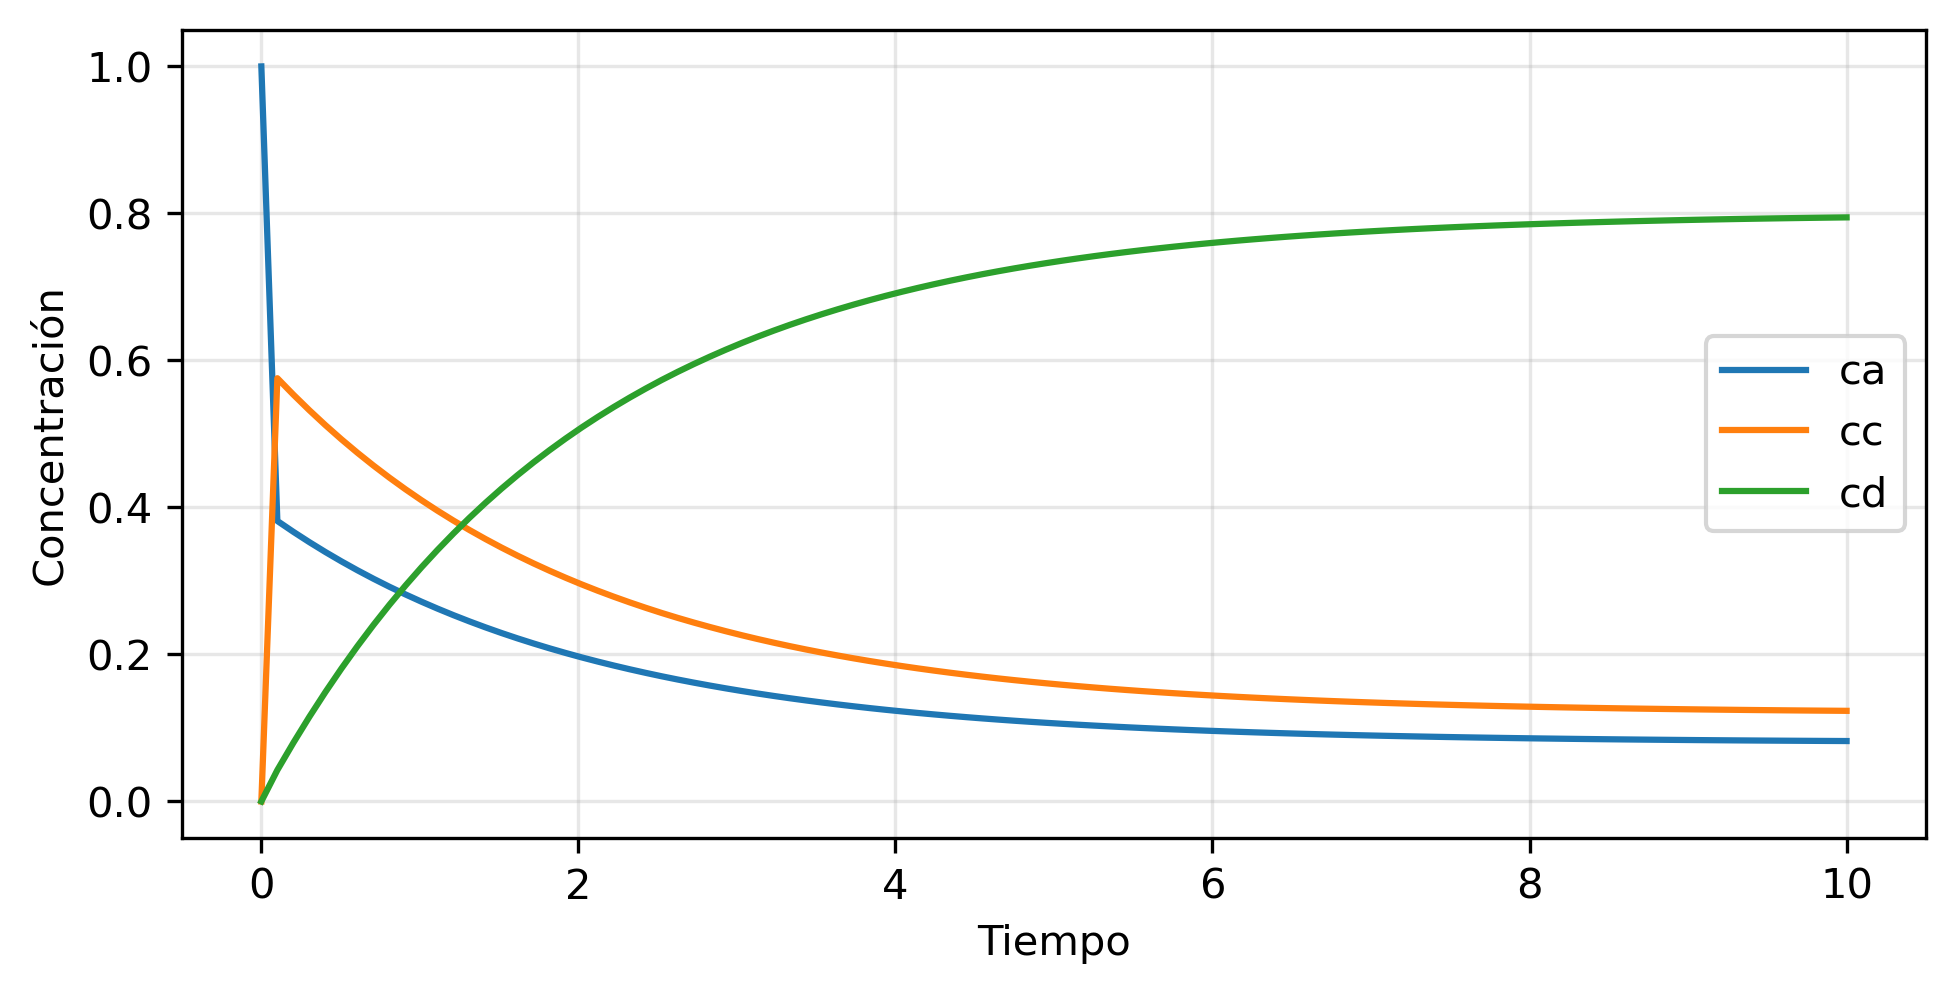

In [75]:
def ode_sys(t, x, params):
    ca, cc, cd = x
    k1, k2, K_1a, K_2a = params
    r1a = -k1 * (ca - cd / K_1a)
    r2a = -k2 * (ca - cc / K_2a)
    dca_dt = r1a + r2a
    dcc_dt = -r2a
    dcd_dt = -r1a
    return [dca_dt, dcc_dt, dcd_dt]


k1, k2 = 1, 100
k1a, k2a = 10, 1.5
x0 = [1, 0, 0]
t_span = (0, 10)
t_eval = np.linspace(*t_span, 100)
params = [k1, k2, k1a, k2a]
sol = scipy.integrate.solve_ivp(
    ode_sys, t_span, x0, args=(params,), t_eval=t_eval, method="BDF"
)
fig, ax = plt.subplots(figsize=(7.5, 3.5), dpi=300)
ax.plot(sol.t, sol.y[0], label="ca")
ax.plot(sol.t, sol.y[1], label="cc")
ax.plot(sol.t, sol.y[2], label="cd")
ax.set_xlabel("Tiempo")

ax.set_ylabel("Concentración")
ax.grid(alpha=0.3)
ax.legend()
fig.savefig(
    "ayu5_reciclo_rxn_multiples_concentraciones_1.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
)

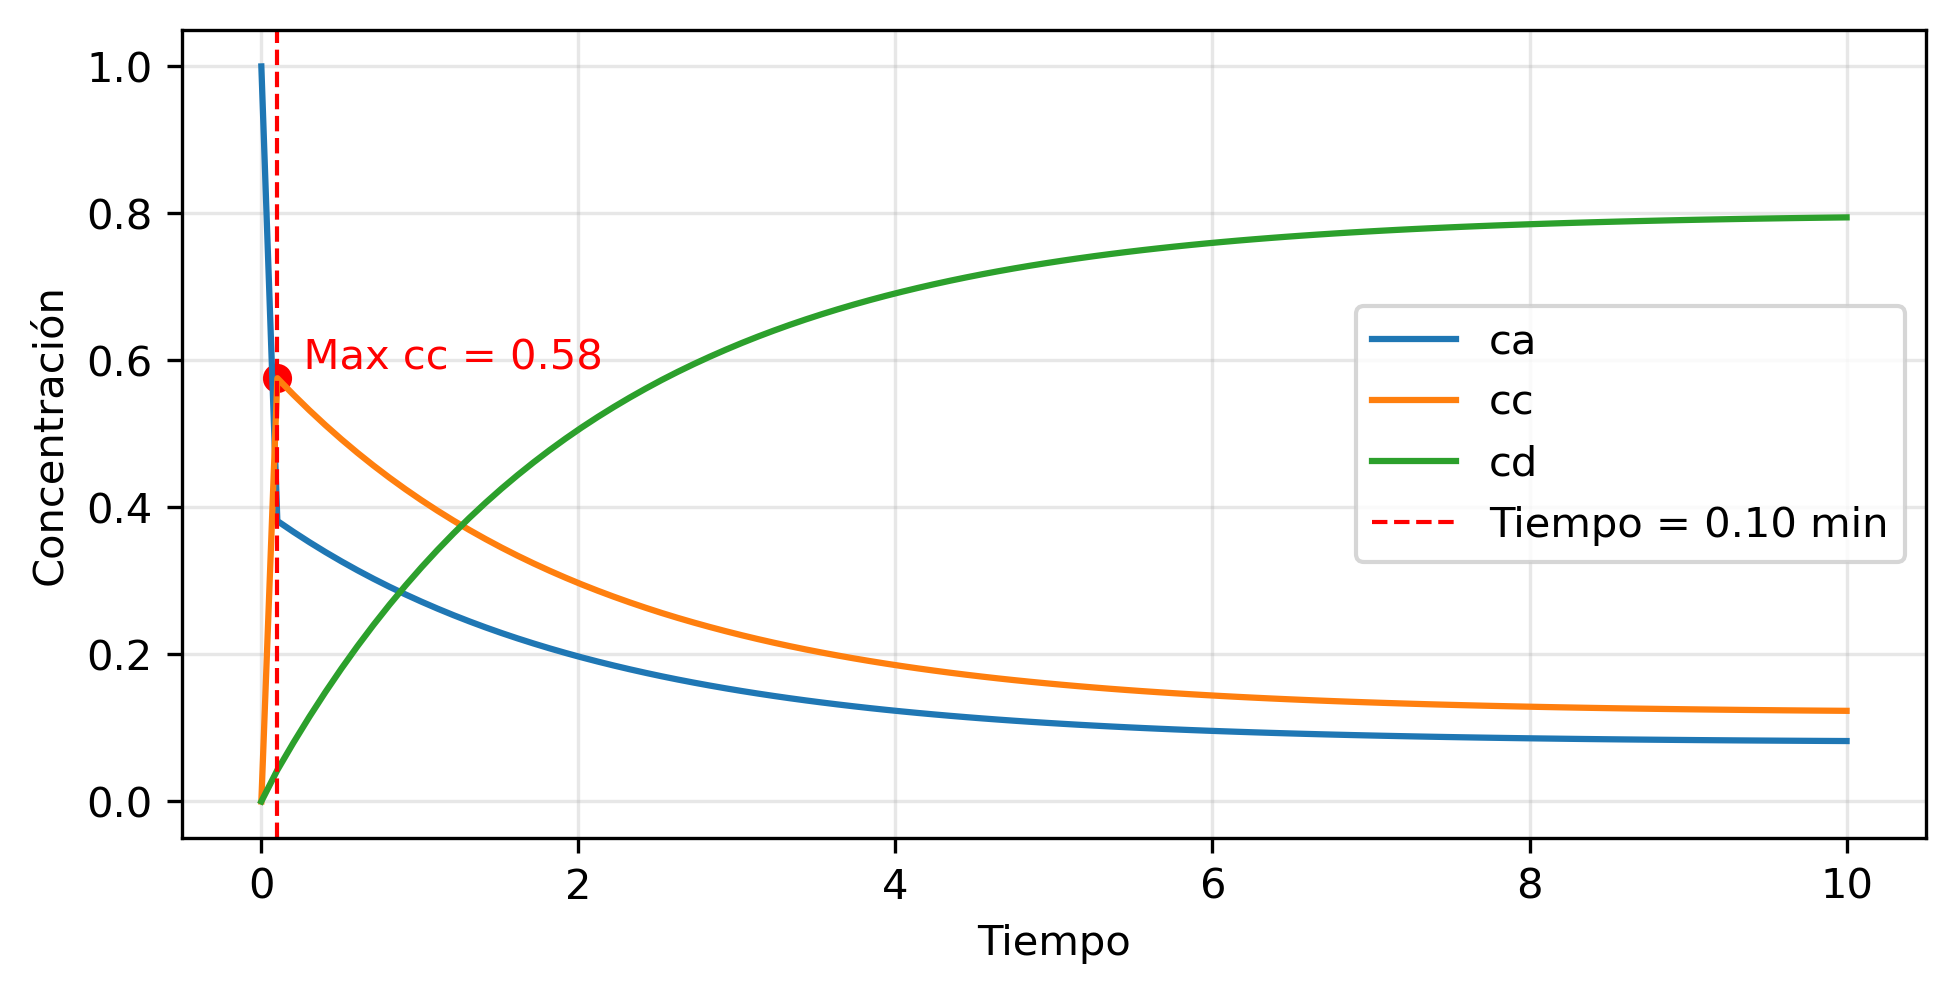

In [82]:
def ode_sys(t, x, params):
    ca, cc, cd = x
    k1, k2, K_1a, K_2a = params
    r1a = -k1 * (ca - cd / K_1a)
    r2a = -k2 * (ca - cc / K_2a)
    dca_dt = r1a + r2a
    dcc_dt = -r2a
    dcd_dt = -r1a
    return [dca_dt, dcc_dt, dcd_dt]


k1, k2 = 1, 100
k1a, k2a = 10, 1.5
x0 = [1, 0, 0]
t_span = (0, 10)
t_eval = np.linspace(*t_span, 100)
params = [k1, k2, k1a, k2a]
sol = scipy.integrate.solve_ivp(
    ode_sys, t_span, x0, args=(params,), t_eval=t_eval, method="BDF"
)
fig, ax = plt.subplots(figsize=(7.5, 3.5), dpi=300)
ax.plot(sol.t, sol.y[0], label="ca")
ax.plot(sol.t, sol.y[1], label="cc")
ax.plot(sol.t, sol.y[2], label="cd")
max_c_index = np.argmax(sol.y[1])
max_c = sol.y[1][max_c_index]
max_c_time = sol.t[max_c_index]
ax.scatter(max_c_time, max_c, color="r")
ax.text(max_c_time, max_c, f"  Max cc = {max_c:.2f}", va="bottom", ha="left", color="r")
ax.axvline(max_c_time, color="r", lw=1, ls="--", label=f"Tiempo = {max_c_time:.2f} min")

ax.set_xlabel("Tiempo")

ax.set_ylabel("Concentración")
ax.grid(alpha=0.3)
ax.legend()
fig.savefig(
    "ayu5_reciclo_rxn_multiples_concentraciones_2.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
)

Steady state concentrations: ca = 0.08, cc = 0.12, cd = 0.80


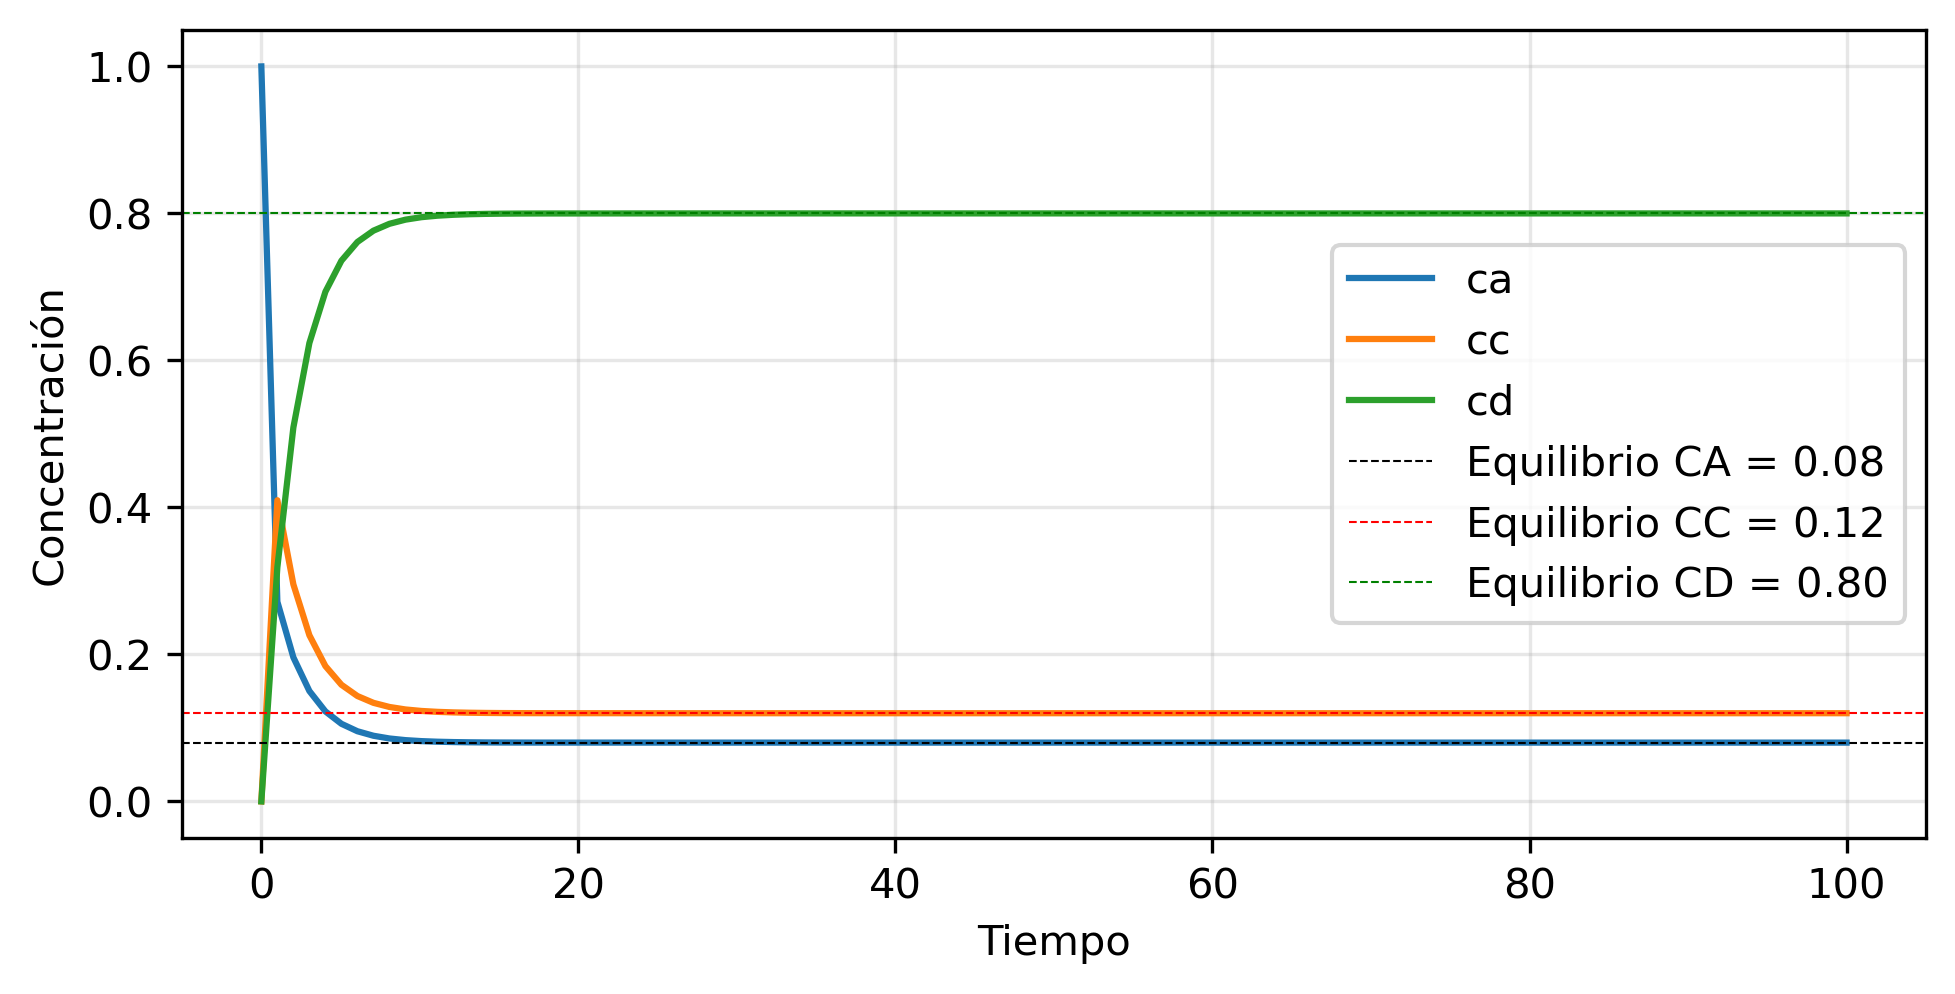

In [93]:
def eqs(x, params):
    ca, cc, cd = x
    k1, k2, K_1a, K_2a = params
    r1a = -k1 * (ca - cd / K_1a)
    r2a = -k2 * (ca - cc / K_2a)
    dca_dt = r1a + r2a
    dcc_dt = -r2a
    dcd_dt = -r1a
    return [dca_dt, dcc_dt, dcd_dt]


k1, k2 = 1, 100
k1a, k2a = 10, 1.5
params = [k1, k2, k1a, k2a]



k1, k2 = 1, 100
k1a, k2a = 10, 1.5
x0 = [1, 0, 0]
t_span = (0, 100)
t_eval = np.linspace(*t_span, 100)
params = [k1, k2, k1a, k2a]
sol = scipy.integrate.solve_ivp(
    ode_sys, t_span, x0, args=(params,), t_eval=t_eval, method="BDF"
)
initial_guess = sol.y[:, -1]  # Usamos la última concentración como guess inicial
steady_state = scipy.optimize.fsolve(eqs, initial_guess, args=(params,))
print(
    f"Steady state concentrations: ca = {steady_state[0]:.2f}, cc = {steady_state[1]:.2f}, cd = {steady_state[2]:.2f}"
)

fig, ax = plt.subplots(figsize=(7.5, 3.5), dpi=300)
ax.plot(sol.t, sol.y[0], label="ca")
ax.plot(sol.t, sol.y[1], label="cc")
ax.plot(sol.t, sol.y[2], label="cd")
ax.axhline(steady_state[0], color="k", lw=0.5, ls="--", label=f"Equilibrio CA = {steady_state[0]:.2f}")
ax.axhline(steady_state[1], color="r", lw=0.5, ls="--", label=f"Equilibrio CC = {steady_state[1]:.2f}")
ax.axhline(steady_state[2], color="g", lw=0.5, ls="--", label=f"Equilibrio CD = {steady_state[2]:.2f}")
ax.set_xlabel("Tiempo")

ax.set_ylabel("Concentración")
ax.grid(alpha=0.3)
ax.legend()
fig.savefig(
    "ayu5_reciclo_rxn_multiples_concentraciones_3.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
)

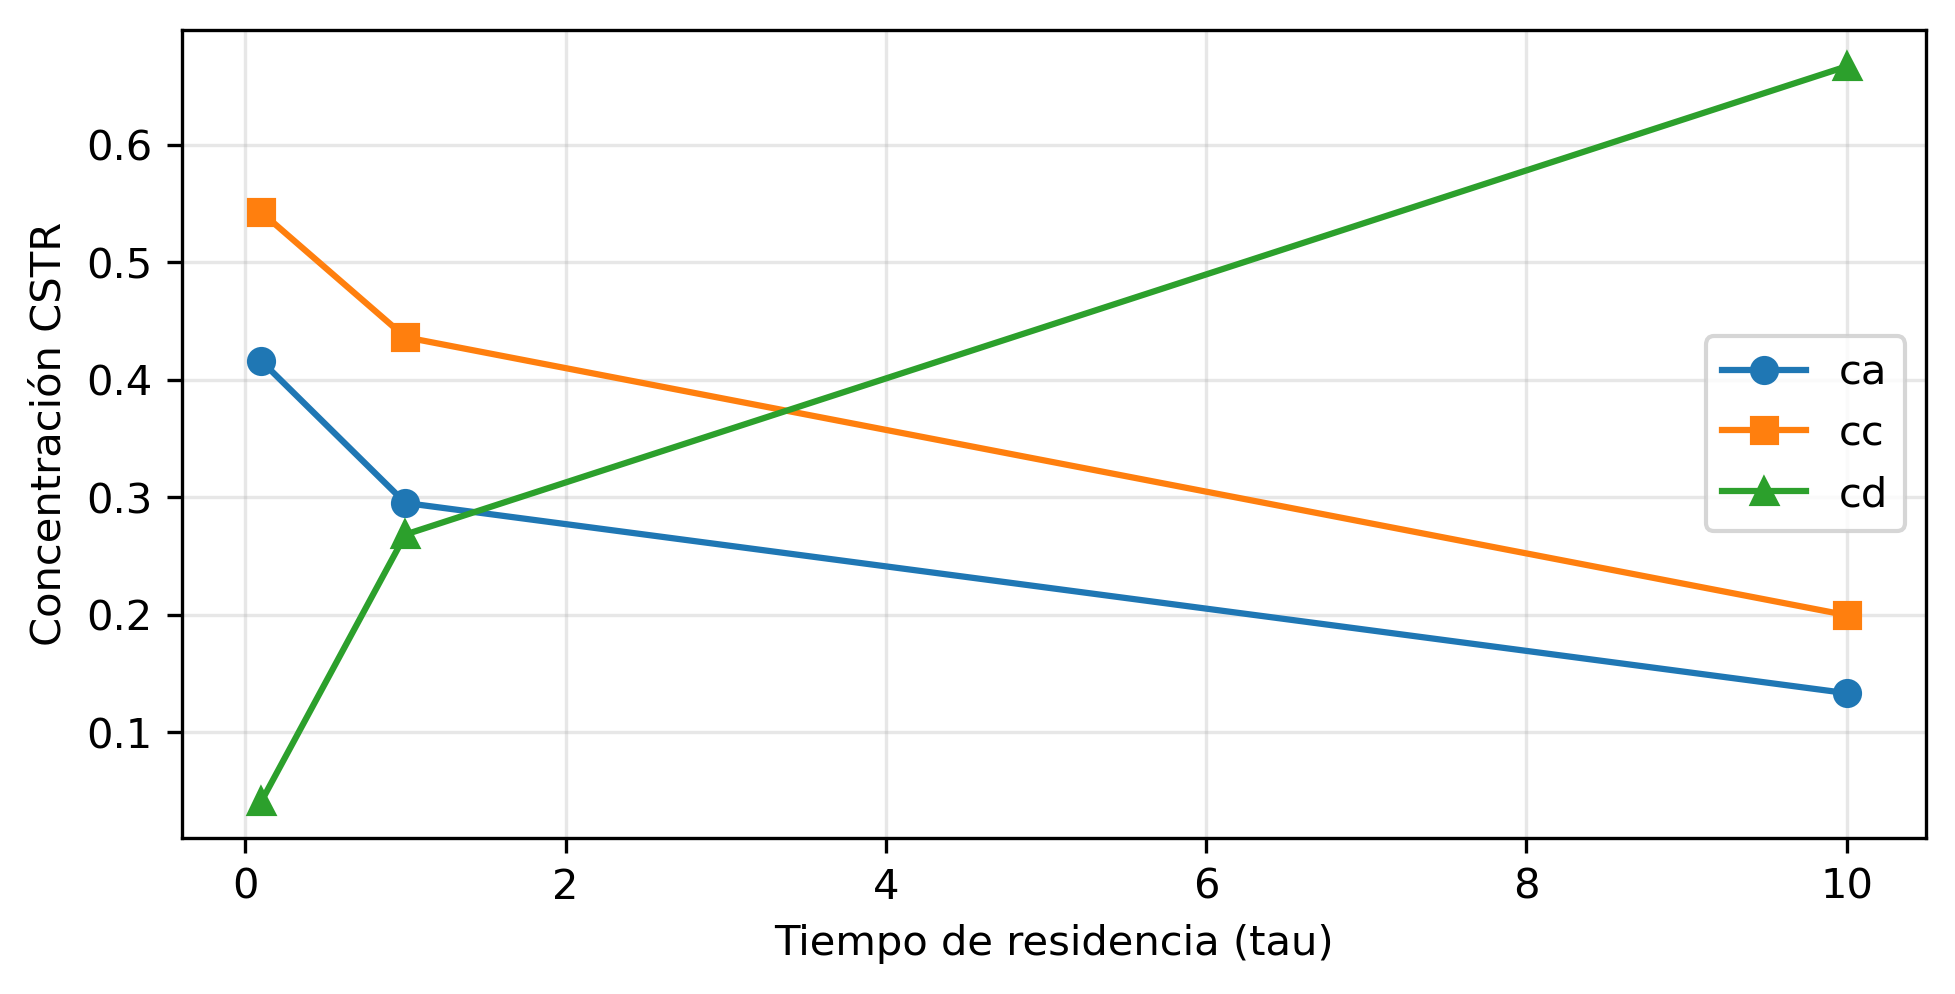

In [104]:
def eqs(x, params):
    ca, cc, cd = x
    k1, k2, K_1a, K_2a, tau, ca0 = params
    eq1 = ca0 - ca - k1 * (ca - cd / K_1a) * tau - k2 * (ca - cc / K_2a) * tau
    eq2 = -cd + k1 * (ca - cd / K_1a) * tau
    eq3 = -cc + k2 * (ca - cc / K_2a) * tau

    return [eq1, eq2, eq3]

k1, k2 = 1, 100
k1a, k2a = 10, 1.5
ca0 = 1
ca = []
cc = []
cd = []
for t in [0.1, 1, 10]:
    tau = t
    params = [k1, k2, k1a, k2a, tau, ca0]
    initial_guess = [0.5, 0.5, 0.5]  # Guess inicial para las concentraciones
    res_cstr = scipy.optimize.fsolve(eqs, initial_guess, args=(params,))
    ca.append(res_cstr[0])
    cc.append(res_cstr[1])
    cd.append(res_cstr[2])
        
fig, ax = plt.subplots(figsize=(7.5, 3.5), dpi=300)
taus = [0.1, 1, 10]
ax.plot(taus, ca, label="ca", marker='o')
ax.plot(taus, cc, label="cc", marker='s')
ax.plot(taus, cd, label="cd", marker='^')
ax.set_xlabel("Tiempo de residencia (tau)")
ax.set_ylabel("Concentración CSTR")

ax.legend()
ax.grid(alpha=0.3)
fig.savefig(
    "ayu5_reciclo_rxn_multiples_concentraciones_cstr.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
    transparent=True,
)